In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
tips_df = pd.read_csv('tips.csv')

In [8]:
tips_df.head()

,order_id,day,time,size,smoker,sex,total_bill,tip
0,1,Sun,Dinner,2,No,Female,16.99,1.01
1,2,Sun,Dinner,3,No,Male,10.34,1.66
2,3,Sun,Dinner,3,No,Male,21.01,3.50
3,4,Sun,Dinner,2,No,Male,23.68,3.31
4,5,Sun,Dinner,4,No,Female,24.59,3.61


In [9]:
tips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    244 non-null    int64  
 1   day         244 non-null    object 
 2   time        244 non-null    object 
 3   size        244 non-null    int64  
 4   smoker      244 non-null    object 
 5   sex         244 non-null    object 
 6   total_bill  244 non-null    float64
 7   tip         244 non-null    float64
dtypes: float64(2), int64(2), object(4)
memory usage: 15.4+ KB


In [11]:
tips_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,244.0,NaN,NaN,NaN,122.5,70.580923,1.0,61.75,122.5,183.25,244.0
day,244,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,244,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,244.0,NaN,NaN,NaN,2.569672,0.9511,1.0,2.0,2.0,3.0,6.0
smoker,244,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,244,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_bill,244.0,NaN,NaN,NaN,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,NaN,NaN,NaN,2.998279,1.383638,1.0,2.0,2.9,3.5625,10.0


# Raw insights 

1. There are 244 rows in the DF, no missing values observed across all variables, dtypes are correct.
2. Data is available for Thu, Fri, Sat and Sun and Sat is the top occurence (87).
3. Dinner dominates the dataset (~72%), indicating the data is heavily skewed toward evening dining behavior.
4. Mean size of the group is 2.6, min size is 1, median size is 2, 75th % is 3 and max is 6
5. Non-smokers account for a higher proportion of observations (151 vs 93), indicating a skew toward non-smoking customers.
6. Male customers appear more frequently in the dataset (157 observations), which may indicate sampling imbalance rather than behavioral difference.
7. Average bill is USD19.8, min is USD 3, median is 17.8 USD and max is 51 USD. he average bill is ~$19.8 with a wide spread (std ≈ 8.9), indicating significant variability in spending.
9. Tips average ~$3 (~15% of the average bill), suggesting relatively consistent tipping behavior, min tip 1 USD, median 3 USD and the top 25% pay 3.6 USD and max has been 10 USD


In [15]:
tips_df['day'].value_counts().reset_index()

,day,count
0,Sat,87
1,Sun,76
2,Thur,62
3,Fri,19


### Very less data points for friday !! Why ?

In [16]:
tips_df['time'].value_counts().reset_index()

,time,count
0,Dinner,176
1,Lunch,68


In [141]:
tips_df.groupby(['day', 'time'])['total_bill'].mean().reset_index()

,day,time,total_bill
0,Fri,Dinner,19.663333
1,Fri,Lunch,12.845714
2,Sat,Dinner,20.441379
3,Sun,Dinner,21.410000
4,Thur,Dinner,18.780000
5,Thur,Lunch,17.664754


## Lunch is missing on sat and sun, indicating data incompleteness

In [21]:
tips_df.groupby(['day', 'time'])['tip'].sum()

day   time  
Fri   Dinner     35.28
      Lunch      16.68
Sat   Dinner    260.40
Sun   Dinner    247.39
Thur  Dinner      3.00
      Lunch     168.83
Name: tip, dtype: float64

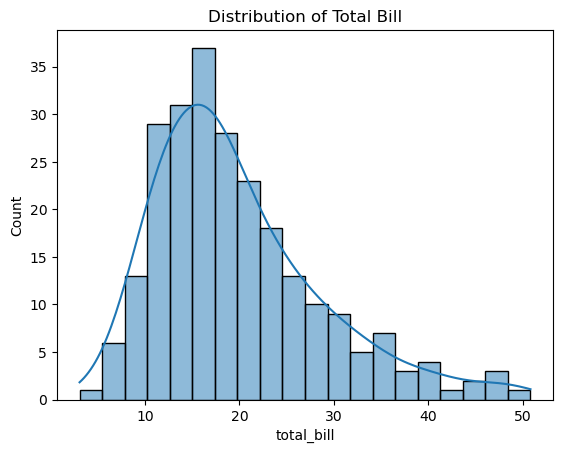

In [42]:
sns.histplot(data=tips_df, x='total_bill', kde=True, bins=20);
plt.title('Distribution of Total Bill');

### Distribution of total bill

1. It is right skewed, smaller number of high value bills pulling the distribution to right
2. Most bills in the range 10-20 dollars
3. Higher values reach up to 50 dollars


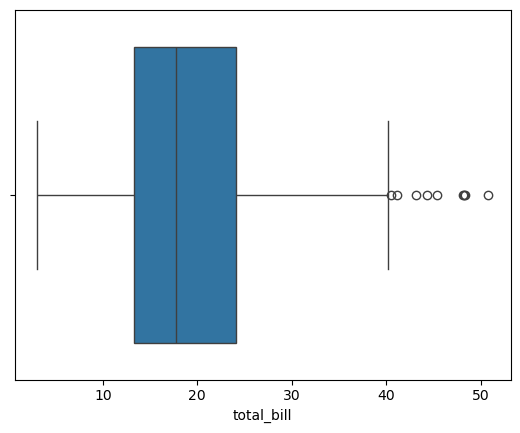

In [25]:
sns.boxplot(data=tips_df, x='total_bill');

### The distribution is right-skewed, with a few high-value bills acting as outliers.

Text(0.5, 0, 'Tip in USD')

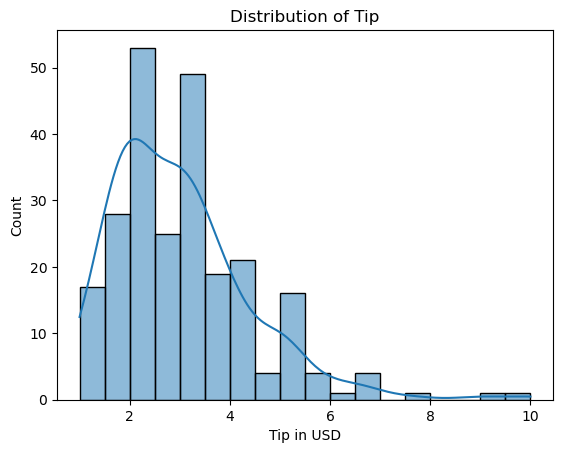

In [62]:
sns.histplot(data=tips_df, x='tip', kde=True);
plt.title('Distribution of Tip');
plt.xlabel('Tip in USD')


### Tip distribution is right-skewed, with most tips clustered around 2–3 USD and a few high-value tips extending the upper tail.

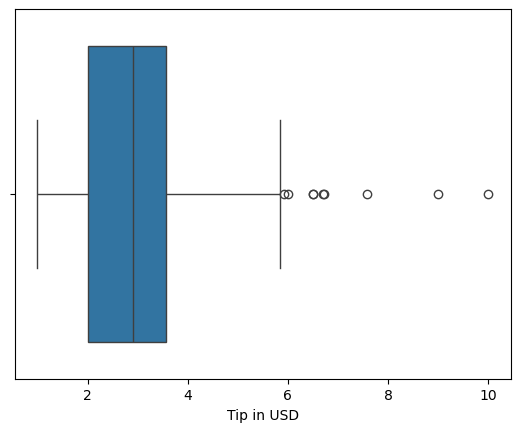

In [60]:
sns.boxplot(data=tips_df, x='tip');
plt.xlabel('Tip in USD');

### Tips upto 6USD considered normal. There are some outliers pulling the distribution to the right. 

## Average tip is ~3 USD which is 15% of Average total bill ~ 15 USD 

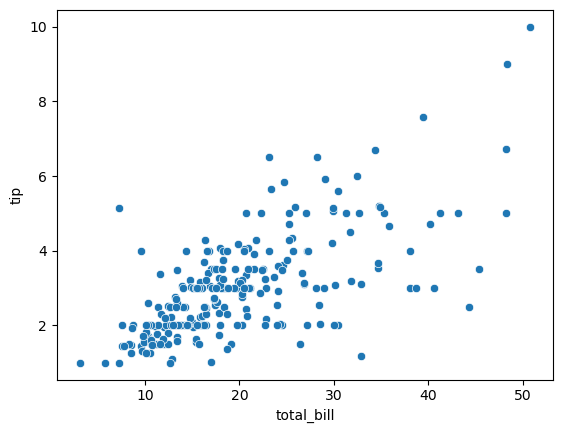

In [66]:
sns.scatterplot(data=tips_df, x='total_bill', y='tip');

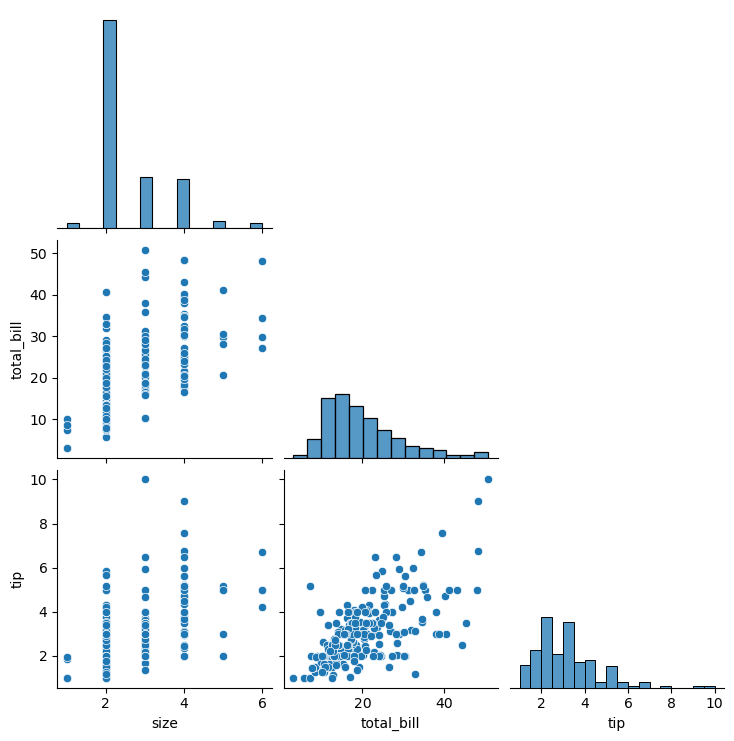

In [74]:
sns.pairplot(tips_df.drop(columns=['order_id']), corner=True);

1. Tip & total bill, strong positive correlation. higher the bill, higher the tip
2. size of the group is typically around 2-4 where the most bills are clustered
3. size influences the tip value but not as strongly as total bill value, indicates that tip behaviour is more driven by spend than group size

<Axes: xlabel='day', ylabel='count'>

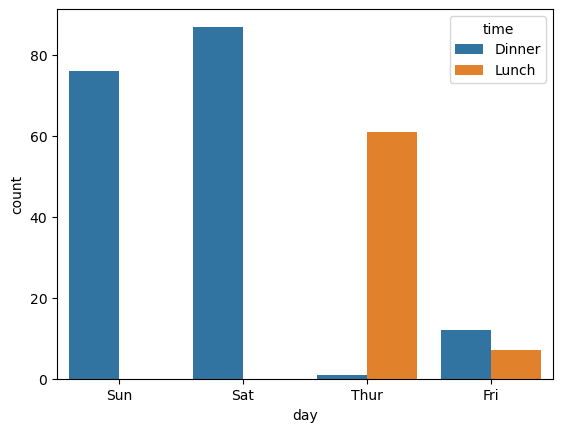

In [119]:
sns.countplot(data=tips_df, x='day', hue='time')

1. Saturday and Sunday has recorded more evening dining
2. Thursday recorded more lunch compared to dinner
3. Friday recorded more dinner compared to lunch

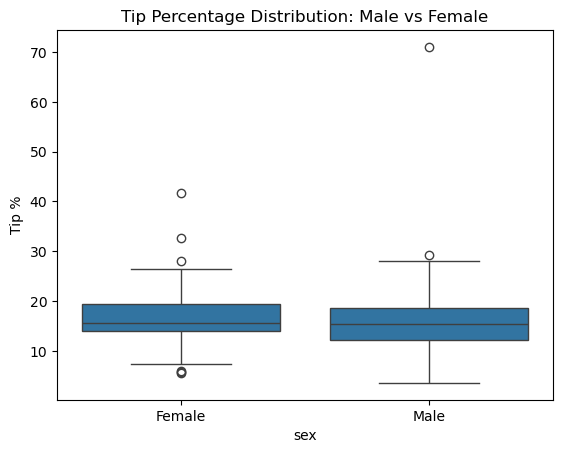

In [114]:
tips_df['tip_pct'] = tips_df['tip']/tips_df['total_bill']*100 # who tips a higher percentage of their bill

sns.boxplot(data=tips_df, x='sex', y='tip_pct')
plt.ylabel('Tip %')
plt.title('Tip Percentage Distribution: Male vs Female');

### The tipping behaviour between male and female customers is broadly similar, falling in the tipping ranges between 12-18% of the total bill value. The observed outliers are likely explained by the presence of small bill value and a normal tip inflating the tip %. 

<Axes: xlabel='sex', ylabel='total_bill'>

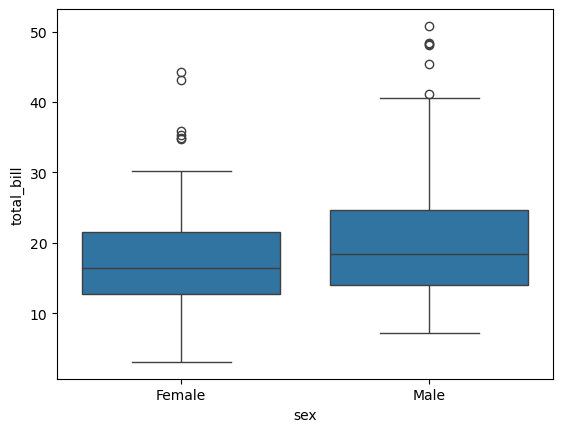

In [108]:
sns.boxplot(data=tips_df, x='sex', y='total_bill')

### Total bill amounts are broadly similar across both genders, with Male having slightly higher median values and more variability. Also, high value outliers are observed in the Male group.  



<Axes: xlabel='smoker', ylabel='total_bill'>

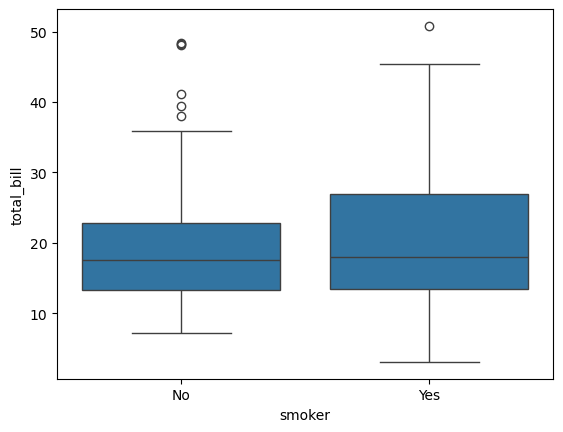

In [120]:
sns.boxplot(data=tips_df, x='smoker', y='total_bill')

### Total bill distribution is similar across smokers and non-smokers, though smokers show slightly higher variability and some higher-value outliers.

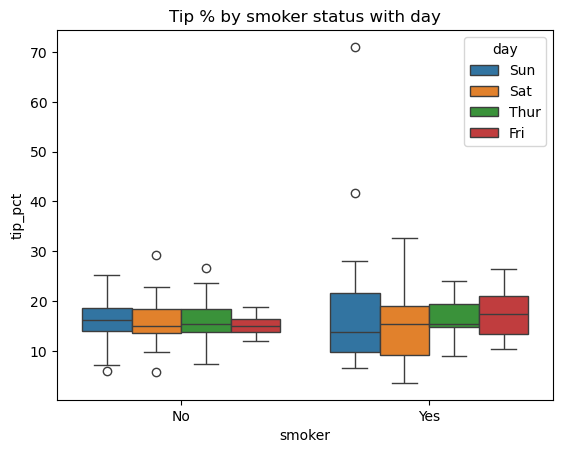

In [136]:
sns.boxplot(data=tips_df, x='smoker', y='tip_pct', hue='day')
plt.title('Tip % by smoker status with day');

### Tipping behavior appears broadly similar between smokers and non-smokers, with only a marginally higher median tip among smokers.

In [126]:
tips_df['size'].value_counts()

size
2    156
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64

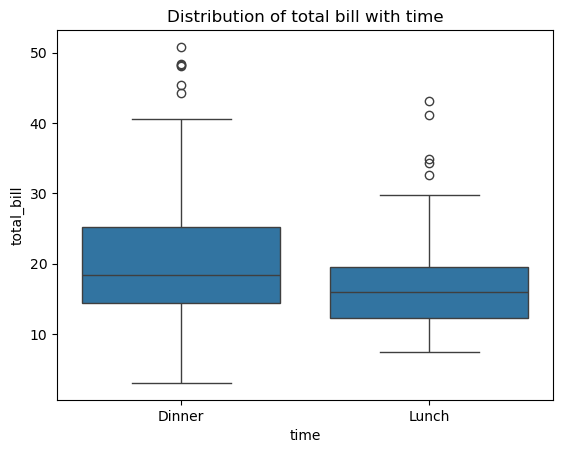

In [137]:
sns.boxplot(data=tips_df, x='time', y='total_bill')
plt.title('Distribution of total bill with time');

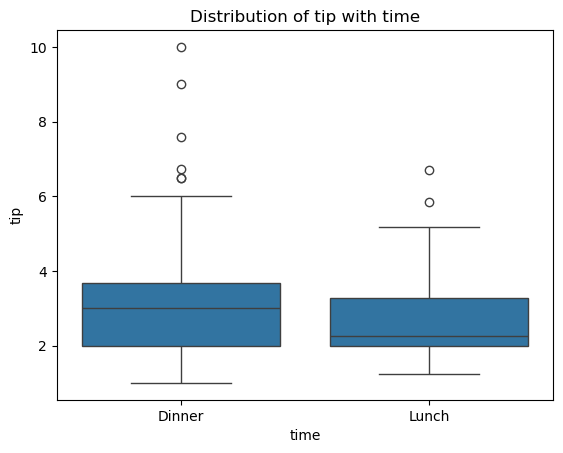

In [138]:
sns.boxplot(data=tips_df, x='time', y='tip')
plt.title('Distribution of tip with time');

1. Total bill value for Dinner is highly variable compared to lunch with the median also being marginally higher
2. Absolute tip also shows a similar behavior since total bill and tip are strongly correlated
3. Outliers observed in both plots are more for customers who dined in the evening

Text(0.5, 1.0, 'Total bill distribution with group size')

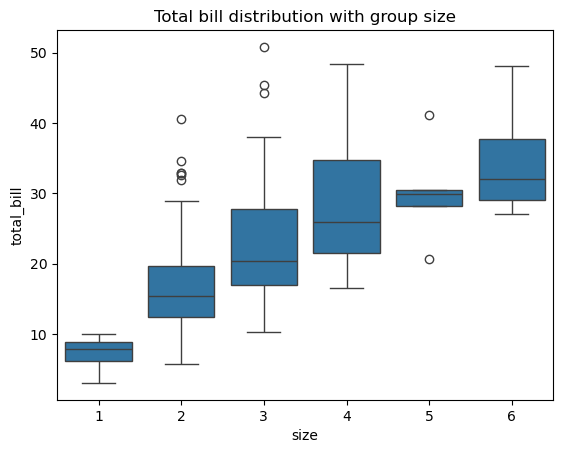

In [131]:
sns.boxplot(data=tips_df, x='size', y='total_bill')
plt.title('Total bill distribution with group size')

Text(0.5, 1.0, 'Tip distribution with group size')

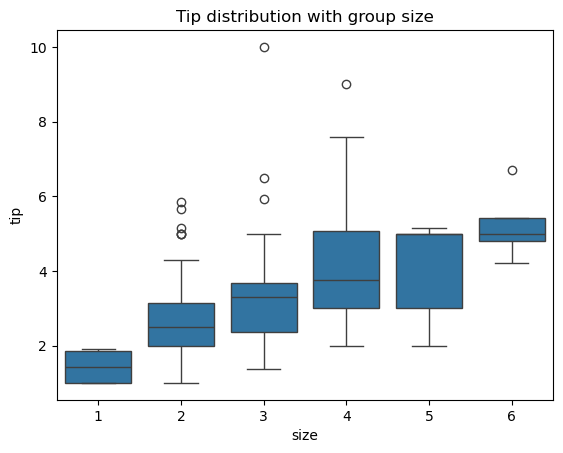

In [130]:
sns.boxplot(data=tips_df, x='size', y='tip')
plt.title('Tip distribution with group size')

1. Median bill value increases with group size and seen to be inconsitent for sizes above 4, likely due to small sample size.
2. Larger groups tend to leave higher absolute tip but the relationship is not strongly direct suggesting that total_bill is the primary driver for tip.

In [142]:
tips_df.groupby(['day', 'time'])[['total_bill', 'tip', 'tip_pct']].mean().reset_index().round(2)

,day,time,total_bill,tip,tip_pct
0,Fri,Dinner,19.66,2.94,15.89
1,Fri,Lunch,12.85,2.38,18.88
2,Sat,Dinner,20.44,2.99,15.32
3,Sun,Dinner,21.41,3.26,16.69
4,Thur,Dinner,18.78,3.00,15.97
5,Thur,Lunch,17.66,2.77,16.13


#### Higher avg tip % in friday lunch appears to be due to lower average bill size and not high absolute tips. 

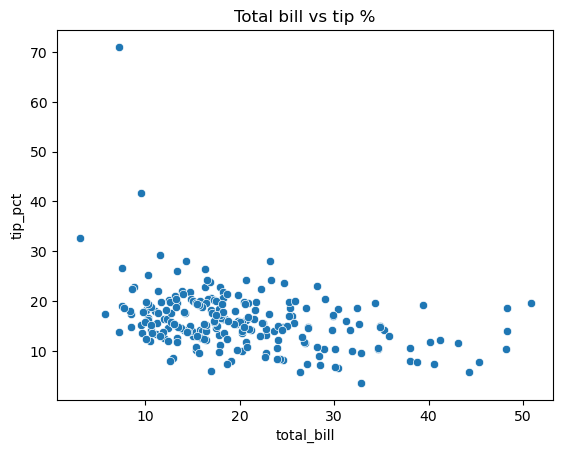

In [144]:
sns.scatterplot(data=tips_df, x='total_bill', y='tip_pct');
plt.title('Total bill vs tip %');

#### There is a weak negative correlation between tip_pct and total_bill since smaller bills tend to inflate the tip_pct even with a normal tip

In [145]:
tips_df['total_bill'].max()

50.81

In [146]:
bins = [0, 10, 20, 30, 40, 60]
labels = ['0-10', '10-20', '20-30', '30-40', '40+']

tips_df['bill_bucket'] = pd.cut(tips_df['total_bill'], labels=labels, bins=bins)

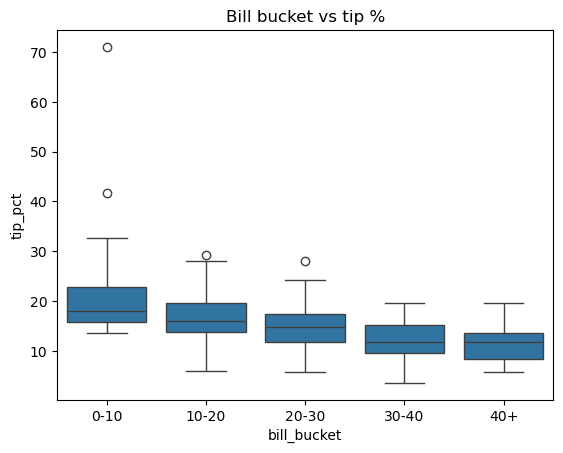

In [153]:
sns.boxplot(data=tips_df, x='bill_bucket', y='tip_pct')
plt.title('Bill bucket vs tip %');

1. tip % appears to be higher for small bills, while consistent for bill values above 10 usd with tip % betweein 10-20% roughly

<Axes: xlabel='bill_bucket', ylabel='tip_pct'>

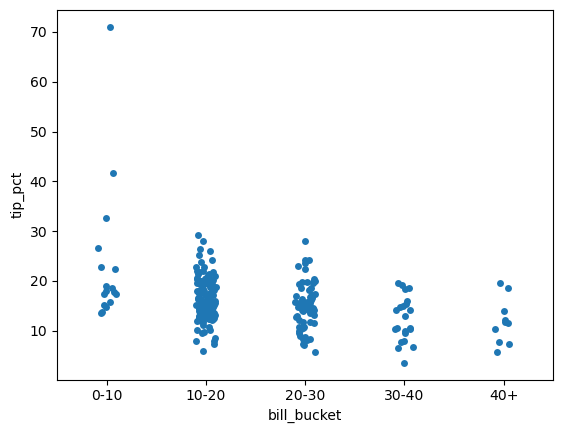

In [155]:
sns.stripplot(data=tips_df, x='bill_bucket', y='tip_pct')

In [156]:
tips_df['bill_bucket'].value_counts()

bill_bucket
10-20    130
20-30     65
30-40     22
0-10      17
40+       10
Name: count, dtype: int64

In [161]:
tips_df.groupby('time')['total_bill'].sum().reset_index()

,time,total_bill
0,Dinner,3660.30
1,Lunch,1167.47


In [162]:
tips_df.groupby('time')['tip'].sum().reset_index()

,time,tip
0,Dinner,546.07
1,Lunch,185.51


### More bills appear to come from the 10-30 USD range

## Final Insights 

#### Overall Pattern:
1. Total bill and tip show a clear positive relationship
2. Most bills fall in the range 10-30 USD

#### Tipping Behaviour 
1. Most customers tip ~10-20% of the total bill
2. Small bills show high variability in tip %
3. Tip % stabilises as bill size increases

#### Customer Segments
1. Male and Female customers show broadly similar tipping behaviour, with tip% falling in the range of ~12-18%
2. Smokers and non-smokers also show broadly similar tipping behaviour
3. No consistent variation in tipping behaviour across days
4. Total bill value for Dinner is highly variable compared to lunch with the median also being marginally higher
5. Dinner makes ~3x more revenue than Lunch, driven by higher volume and larger bills

#### Group Size Impact
1. Larger groups yield higher total bills
2. Tip increases with group size, but not proportionally
3. Total bill is the primary driver for tip
